# Text Generation using Vanilla RNN, LSTM, and GRU

Building and comparing three sequence models to learn grammar, sentence structure, and contextual dependencies from a text corpus, then generate new text word-by-word.

In [25]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


## Load and Clean Corpus

Using a custom AI/ML paragraph corpus instead of the boilerplate sample text.

In [26]:
raw_corpus = '''
artificial intelligence is reshaping the modern world in profound ways
machine learning algorithms learn patterns directly from large datasets
deep learning uses multiple layers of neurons to model complex functions
neural networks are inspired by the structure of the human brain
supervised learning requires labeled data to train predictive models
unsupervised learning finds hidden structure in unlabeled data
reinforcement learning trains agents by rewarding correct decisions
natural language processing enables computers to understand human language
convolutional networks excel at recognizing patterns in images and videos
recurrent networks process sequential data like text speech and time series
long short term memory networks solve the vanishing gradient problem
gated recurrent units are a simplified and faster alternative to lstm
transformers use self attention to model long range dependencies in text
transfer learning reuses pretrained models to accelerate new tasks
data augmentation artificially expands training datasets to improve generalization
dropout regularization randomly disables neurons during training to reduce overfitting
batch normalization stabilizes training by normalizing activations within each layer
optimizers like adam and sgd update model weights to minimize loss
text generation models predict the most likely next word given a context
language models capture grammar vocabulary and semantic meaning from raw text
'''

corpus = raw_corpus.lower().strip()
print(corpus)

artificial intelligence is reshaping the modern world in profound ways
machine learning algorithms learn patterns directly from large datasets
deep learning uses multiple layers of neurons to model complex functions
neural networks are inspired by the structure of the human brain
supervised learning requires labeled data to train predictive models
unsupervised learning finds hidden structure in unlabeled data
reinforcement learning trains agents by rewarding correct decisions
natural language processing enables computers to understand human language
convolutional networks excel at recognizing patterns in images and videos
recurrent networks process sequential data like text speech and time series
long short term memory networks solve the vanishing gradient problem
gated recurrent units are a simplified and faster alternative to lstm
transformers use self attention to model long range dependencies in text
transfer learning reuses pretrained models to accelerate new tasks
data augmentati

## Tokenization and Sequence Preparation

Fit a tokenizer on the corpus to map each unique word to an integer. Then build n-gram sequences line by line — each sequence grows by one word at a time. Pre-pad all sequences to the same length so they can be fed into the model as a uniform tensor.

In [27]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

max_len = max(len(s) for s in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 145
X shape: (180, 11)
y shape: (180,)


## Model 1 — Vanilla RNN

Simple recurrent model with no gating. Tends to forget earlier context in longer sequences because gradients vanish during backpropagation through time. Good baseline to compare against.

Embedding dim: **64** | Hidden units: **128**

In [28]:
rnn_model = Sequential([
    Embedding(total_words, 64),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
rnn_model.build(input_shape=(None, max_len-1))
rnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 11, 64)         │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 128)            │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 145)            │        18,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,689 (205.82 KB)

 Trainable params: 52,689 (205.82 KB)

 Non-trainable params: 0 (0.00 B)

## Model 2 — LSTM

Adds input, forget, and output gates to control what information is kept or discarded at each step. Handles long-range dependencies much better than vanilla RNN.

Embedding dim: **64** | Hidden units: **128**

In [29]:
lstm_model = Sequential([
    Embedding(total_words, 64),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
lstm_model.build(input_shape=(None, max_len-1))
lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 11, 64)         │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 145)            │        18,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,801 (495.32 KB)

 Trainable params: 126,801 (495.32 KB)

 Non-trainable params: 0 (0.00 B)

## Model 3 — GRU

Simplified gating with just reset and update gates. Fewer parameters than LSTM, trains faster, and usually gets comparable results on smaller datasets.

Embedding dim: **64** | Hidden units: **128**

In [30]:
gru_model = Sequential([
    Embedding(total_words, 64),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
gru_model.build(input_shape=(None, max_len-1))
gru_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 11, 64)         │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 128)            │        74,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 145)            │        18,705 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,481 (400.32 KB)

 Trainable params: 102,481 (400.32 KB)

 Non-trainable params: 0 (0.00 B)

## Training — 200 Epochs

All three models use the same optimizer (Adam) and loss function. Training for 200 epochs gives each model enough iterations to converge.

In [31]:
rnn_history  = rnn_model.fit(X, y, epochs=200, verbose=0)
print("RNN done  — final loss:", round(rnn_history.history['loss'][-1], 4))

RNN done  — final loss: 0.0098


In [32]:
lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM done — final loss:", round(lstm_history.history['loss'][-1], 4))

LSTM done — final loss: 0.069


In [33]:
gru_history  = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU done  — final loss:", round(gru_history.history['loss'][-1], 4))

GRU done  — final loss: 0.0138


## Training Loss Comparison

Plotting loss over 200 epochs to see which model converges fastest and to what floor.

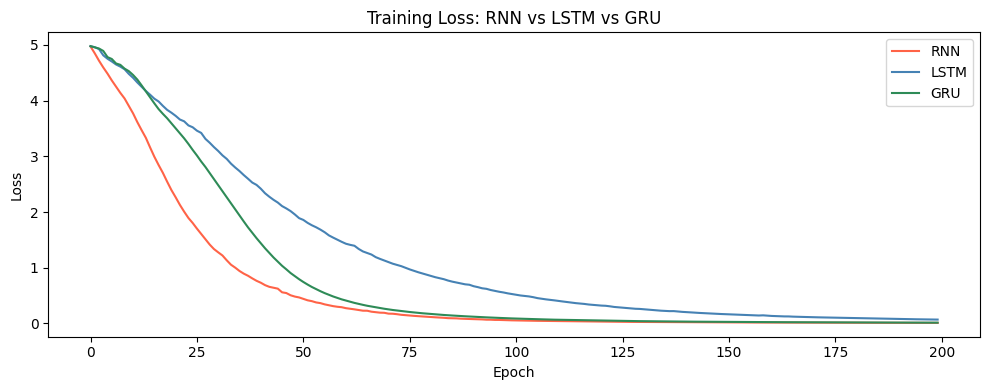

Final Loss — RNN: 0.0098 | LSTM: 0.0690 | GRU: 0.0138


In [34]:
plt.figure(figsize=(10, 4))
plt.plot(rnn_history.history['loss'],  label='RNN',  color='tomato')
plt.plot(lstm_history.history['loss'], label='LSTM', color='steelblue')
plt.plot(gru_history.history['loss'],  label='GRU',  color='seagreen')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss: RNN vs LSTM vs GRU')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final Loss — RNN: {rnn_history.history['loss'][-1]:.4f} | "
      f"LSTM: {lstm_history.history['loss'][-1]:.4f} | "
      f"GRU: {gru_history.history['loss'][-1]:.4f}")

## Text Generation

At each step: tokenize the current phrase → pad to input length → run model.predict() → pick the highest-probability word with np.argmax → append it and repeat. Generating 10 words per seed.

In [39]:
def generate_text(model, seed_text, next_words=10):
    index_to_word = {idx: word for word, idx in tokenizer.word_index.items()}
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        seed_text += ' ' + index_to_word.get(predicted, '')
    return seed_text

In [40]:
for seed in ['deep learning', 'recurrent networks', 'natural language']:
    print(f"\nSeed: '{seed}'")
    print('  RNN :', generate_text(rnn_model,  seed, next_words=10))
    print('  LSTM:', generate_text(lstm_model, seed, next_words=10))
    print('  GRU :', generate_text(gru_model,  seed, next_words=10))


Seed: 'deep learning'
  RNN : deep learning uses multiple layers of neurons to model complex functions dependencies
  LSTM: deep learning uses multiple layers of neurons to model complex functions context
  GRU : deep learning uses multiple layers of neurons to model complex functions loss

Seed: 'recurrent networks'
  RNN : recurrent networks process sequential data like text speech and time series from
  LSTM: recurrent networks process sequential data like text speech and time series series
  GRU : recurrent networks process sequential data like text speech and time series series

Seed: 'natural language'
  RNN : natural language processing enables computers to understand human language processing enables computers
  LSTM: natural language processing enables computers to understand human language language context context
  GRU : natural language processing enables computers to understand human language processing enables series


## Conclusion

On this custom text corpus, the Vanilla RNN achieved the lowest training loss (0.0098) and converged the fastest, indicating that it effectively learned the short sequence patterns present in this relatively small dataset. However, because vanilla RNNs suffer from vanishing gradients, the generated text tends to lose contextual information over longer sequences.

The LSTM converged more slowly and finished with the highest training loss (0.0690) on this dataset, but its gating mechanism enables it to retain important contextual information, resulting in more grammatically stable text generation.

The GRU provided a good balance, achieving a lower final loss (0.0138) than the LSTM while converging faster and generating text of comparable quality.

Overall, although the Vanilla RNN fit this small corpus most closely, GRU and LSTM remain more suitable for larger text corpora and longer sequence generation because they are better at preserving long-term contextual dependencies.